In [33]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16

import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
BATCH_SIZE=32
IMAGE_SIZE=256
CHANNELS=3
EPOCHS=50

In [35]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
        'ds',
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="sparse",
)

Found 8000 images belonging to 10 classes.


In [36]:
class_names = list(train_generator.class_indices.keys())
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [37]:
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)

validation_generator = validation_datagen.flow_from_directory(
        'vs',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 1000 images belonging to 10 classes.


In [38]:
test_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)

test_generator = test_datagen.flow_from_directory(
        'ts',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 1000 images belonging to 10 classes.


In [39]:
plt.figure(figsize=(12,4))

for image_batch, label_batch in train_generator:
    plt.imshow(image_batch[0])
    plt.title(class_names[int(label_batch[0])])
    plt.axis("off")
    break

In [45]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 10

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)


In [46]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_48 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_48 (MaxPoolin  (None, 127, 127, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_49 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_49 (MaxPoolin  (None, 62, 62, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_50 (Conv2D)          (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_50 (MaxPoolin  (None, 30, 30, 128)    

In [47]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [48]:
history = model.fit(
    train_generator,
    steps_per_epoch=250,
    batch_size=BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=31,
    verbose=1,
    epochs=50,
)

Epoch 1/50
250/250 [==============================] - 312s 1s/step - loss: 1.8265 - accuracy: 0.3046 - val_loss: 1.3653 - val_accuracy: 0.4829
Epoch 2/50
250/250 [==============================] - 297s 1s/step - loss: 1.2149 - accuracy: 0.5533 - val_loss: 1.1358 - val_accuracy: 0.5796
Epoch 3/50
250/250 [==============================] - 301s 1s/step - loss: 0.9136 - accuracy: 0.6719 - val_loss: 0.7575 - val_accuracy: 0.7319
Epoch 4/50
250/250 [==============================] - 303s 1s/step - loss: 0.6930 - accuracy: 0.7519 - val_loss: 0.7107 - val_accuracy: 0.7198
Epoch 5/50
250/250 [==============================] - 300s 1s/step - loss: 0.5321 - accuracy: 0.8116 - val_loss: 0.4202 - val_accuracy: 0.8548
Epoch 6/50
250/250 [==============================] - 303s 1s/step - loss: 0.4216 - accuracy: 0.8499 - val_loss: 0.4422 - val_accuracy: 0.8377
Epoch 7/50
250/250 [==============================] - 304s 1s/step - loss: 0.3707 - accuracy: 0.8675 - val_loss: 0.3748 - val_accuracy: 0.8589

In [49]:
 scores = model.evaluate(test_generator)

32/32 [==============================] - 14s 444ms/step - loss: 0.1639 - accuracy: 0.9610


In [52]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

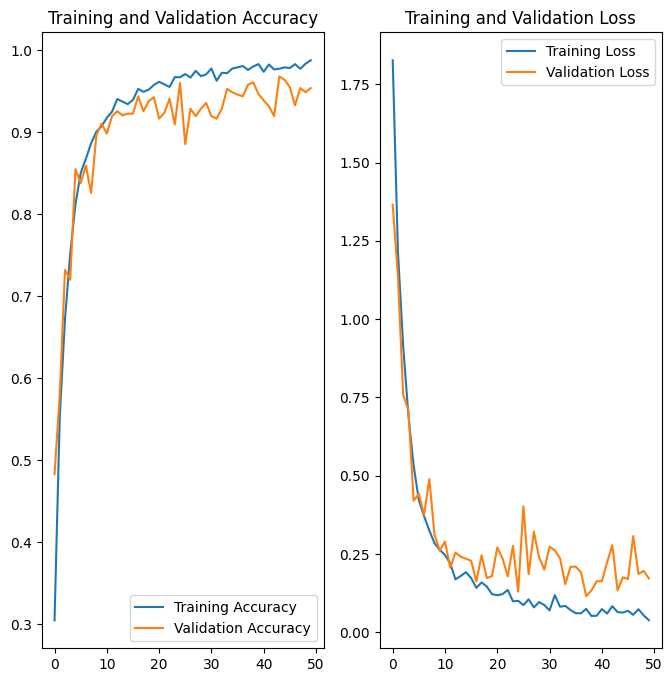

In [56]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

First image to predict
Actual label: Tomato___Early_blight
1/1 [==============================] - 0s 366ms/step
Predicted label: Tomato___Early_blight


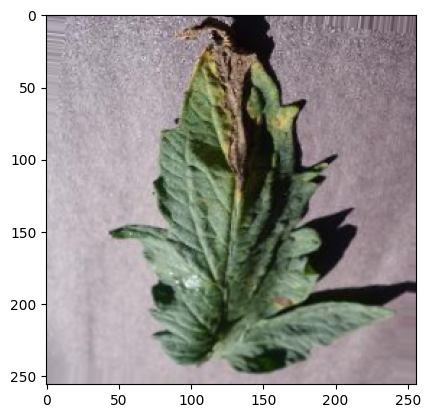

In [57]:
import numpy as np

for image_batch, label_batch in test_generator:

    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("First image to predict")
    plt.imshow(first_image)
    print(f"Actual label: {class_names[first_label]}")
    
    batch_prediction = model.predict(image_batch)
    print(f"Predicted label: {class_names[np.argmax(batch_prediction[0])]}")
    
    break

In [64]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 27ms/step


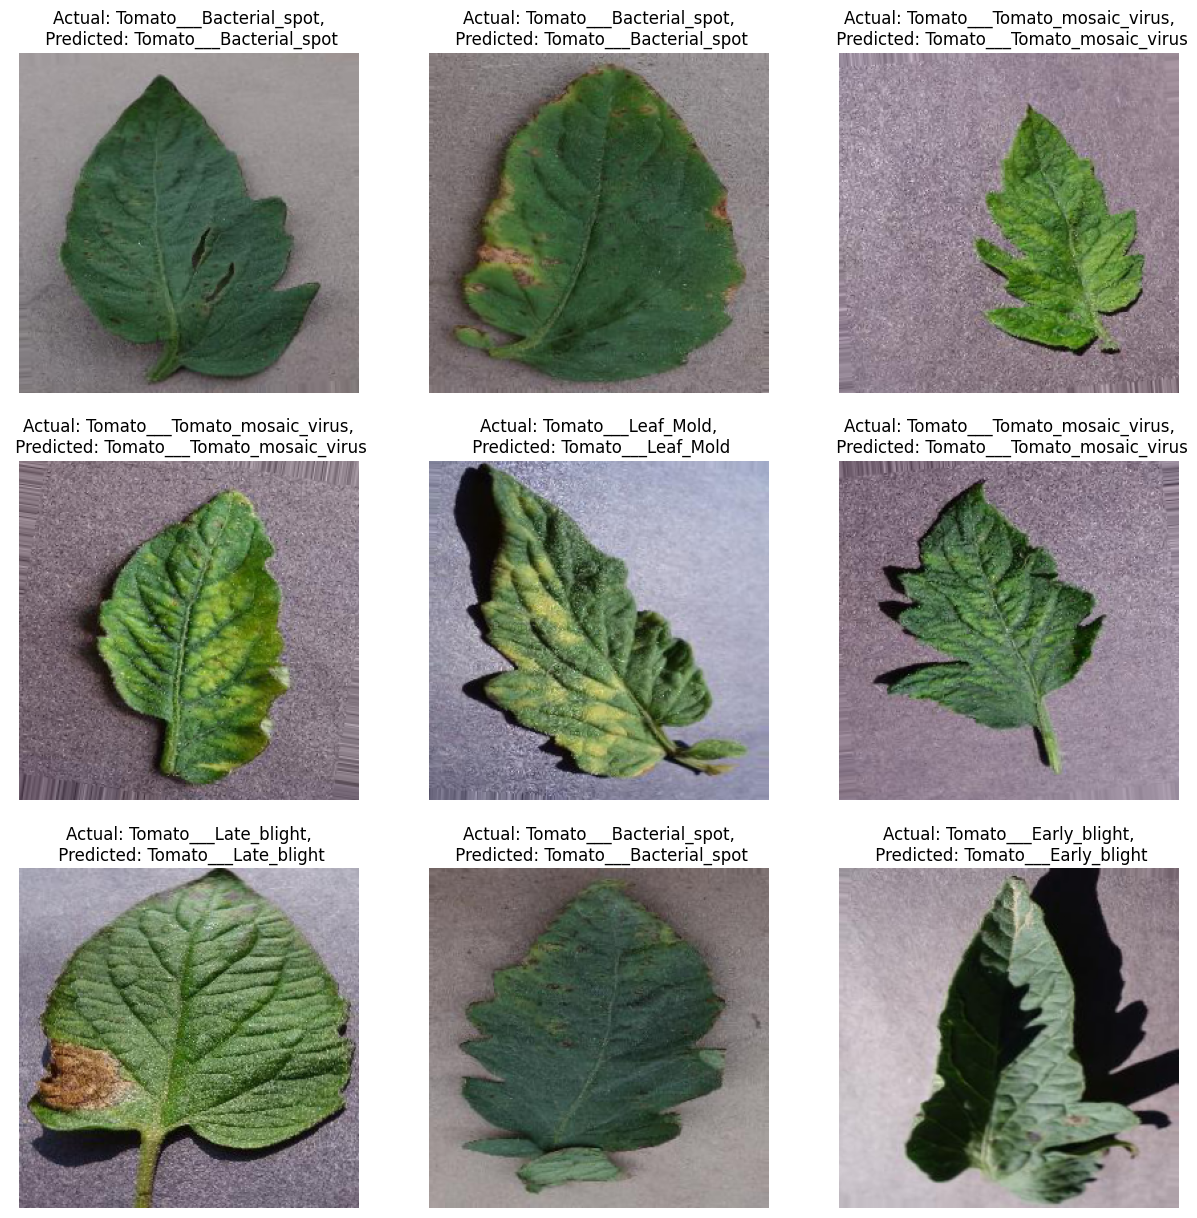

In [72]:
plt.figure(figsize=(15, 15))

for images, labels in test_generator:
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}")
        
        plt.axis("off")
    break
    

In [60]:
model.save("Final.h5")

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

In [ ]:
model = tf.keras.models.load_model('Final.h5')
class_names = ['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [ ]:
def preprocess_image(image):
    image = tf.image.resize(image, (256, 256))
    image = image / 255.0
    image = tf.expand_dims(image, axis=0)
    return image

In [ ]:
def classify_image(image):
    image = preprocess_image(image)
    predictions = model.predict(image)
    predicted_class = class_names[np.argmax(predictions[0])]
    

    return f"Predicted class: {predicted_class}"

In [ ]:
image_input = gr.inputs.Image()
label_output = gr.outputs.Textbox()
iface = gr.Interface(fn=classify_image, inputs=image_input, outputs=label_output)
iface.launch()

